# Simple recursive network for sequence learning

## Setup

In [1]:
import sys
from pathlib import Path
from typing import Callable, Sequence
from tqdm import trange

import numpy as np
import torch
import matplotlib.pyplot as plt

# import local packages
sys.path.append(str(Path().cwd().parents[0]))

from src.data.formater import PandasLoader
from src.data.utils import rand_key_emb_value
from src.utils.args import get_args
from src.utils.logger import add_log_level, setup_logger


In [2]:
# global setup parameters
args = get_args()
# define the verbose level
#available levels: CRITICAL, ERROR, WARNING, INFO, DEBUG, TRACE
logger_level = "DEBUG"


In [3]:
# golbal setup
add_log_level("TRACE", 5)
logger = setup_logger(name="logger", level=logger_level)
logger.info("logger set to info level")
logger.trace("TRACE logger activated")

logger.debug(f"arguments dictionnray: {args}")


INFO - logger set to info level
DEBUG - arguments dictionnray: {'input': PosixPath('/var/home/quatras/Desktop/SRN-statistical-learning-experimentation/data/input/Results_TR_24.xls'), 'format': <Format.FORMAT_1: 2>}


## Data setup


In [4]:
# load data
loader = PandasLoader(args["input"], args["format"])
responses = loader.get()
logger.info(f"subjects response per trial: \n {responses}")

# converting to array of shape (subjects, responses)
responses = responses.to_numpy().T
logger.debug(f"responses with array shape (subjects, responses) = {responses}")

# get set of responses values and their order of appearance (giving them a numerical id) restoring the value from it's encoded index is easy.
unique_vals, encoded = np.unique(responses.reshape(-1), return_inverse=True)
dict_unique_vals = {
    label: encod for label, encod in zip(unique_vals, range(len(unique_vals)))
}
logger.info(f"unique values ={unique_vals}")
logger.info(f"encoded values={encoded}")
logger.info(f"number of labels={len(unique_vals)}")
encoded = encoded.reshape(responses.shape)
logger.debug(f"final encoded shape (subjects, responses)={encoded.shape}")
logger.debug(f"encoded values={encoded}")



INFO - subjects response per trial: 
 Subject    1  2  3  4  5  6  7  8  9  10  ... 51 52 53 54 55 56 57 58 59 60
TrialIndex                                ...                              
0           a  a  a  b  c  a  b  c  a  a  ...  a  a  a  b  c  a  b  c  b  b
1           J  Q  P  M  T  K  I  S  J  Q  ...  J  Q  P  M  T  K  I  S  L  H
2           d  d  d  e  f  d  e  f  d  d  ...  d  d  d  e  f  d  e  f  e  e
3           a  b  b  c  c  b  c  b  a  b  ...  a  b  b  c  c  b  c  b  b  c
4           S  I  O  Y  I  £  Q  H  S  I  ...  S  I  O  Y  I  £  Q  H  K  K
...        .. .. .. .. .. .. .. .. .. ..  ... .. .. .. .. .. .. .. .. .. ..
643         P  N  H  Y  £  G  H  M  P  N  ...  P  N  H  Y  £  G  H  M  H  W
644         d  e  d  e  d  d  f  f  d  e  ...  d  e  d  e  d  d  f  f  f  f
645         c  c  c  c  a  a  c  b  c  c  ...  c  c  c  c  a  a  c  b  b  c
646         O  I  K  ù  I  ù  &  Z  O  I  ...  O  I  K  ù  I  ù  &  Z  N  H
647         f  f  f  f  d  d  f  e  f  f  ...  f  

### Stimulus grid
Each stimulus (key, embeding, value) appear as a colored cell on a gridd. This is translated as an array of zeros with only one cell at 1. 

In [5]:
def make_stimulus_grid(stimulus: list[int]|int, size:int, grid_max: float=1.0, grid_min: float=0.0) -> torch.Tensor:
    """
    Create a grid with a stimulus at the encoded label position.
    Args:
        stimulus (int): The index of the stimulus to be placed in the grid.
        size (int): The size of the grid.
        grid_max (float): The maximum value for the stimulus.
        grid_min (float): The minimum value for the stimulus.

    Returns:
        torch.Tensor: A tensor representing the grid with the stimulus.
    """
    if not isinstance(stimulus, list):
        stimulus = [stimulus]
        
    grid = torch.ones(size) * grid_min
    for s in stimulus:
        grid[s] = grid_max
        
    return grid

In [6]:
first_head = encoded[0, 0]
first_embed = encoded[0, 1]
first_tail = encoded[0, 2]

logger.info(f"first head={first_head}, first embed={first_embed}, first tail={first_tail}")
logger.info(f"first_head={make_stimulus_grid(stimulus=first_head, size=len(unique_vals), grid_max=1.0, grid_min=0.0)}")
logger.info(f"first_embed={make_stimulus_grid(stimulus=first_embed, size=len(unique_vals), grid_max=1.0, grid_min=0.0)}")
logger.info(f"first_tail={make_stimulus_grid(stimulus=first_tail, size=len(unique_vals), grid_max=1.0, grid_min=0.0)}")

INFO - first head=22, first embed=5, first tail=25
INFO - first_head=tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])
INFO - first_embed=tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
INFO - first_tail=tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])


## SRN implementation

![srn elman diagrma](https://web.stanford.edu/group/pdplab/pdphandbook/srn_net.png)

The SRN is regarded as an early precursor to recurrent neural networks (RNNs).
At each time step, the pattern of activations from the hidden layer is copied to the context units for the next time step.
The context units belong to the input layer and are connected to the hidden units.
The output of the hidden layer is then used to compute the network's output.

![SRN basic architecture](https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fwww.researchgate.net%2Fpublication%2F361380872%2Ffigure%2Ffig1%2FAS%3A1169080920875058%401655742020827%2FSchematic-diagram-of-Elman-network-structure-in-simple-recurrent-neural-network.jpg&f=1&nofb=1&ipt=1d5a36f3ef48ba69e88b9f96a9176f2e1ed8232b2019b9d3f7f7335e1ee85f1d)

```mermaid
graph TB;
hidden --> context
input --> hidden
context --> hidden
hidden --> output
```

In [7]:
def make_uniform_tensor(
    extremum: tuple[float, float], shape: Sequence[int], require_grad: bool
):
    """
    Create a tensor with values uniformly distributed between the given extrema.
    Args:
        extremum (tuple[float, float]): The lower and upper bounds of the uniform distribution.
        shape (Sequence[int]): The shape of the tensor to be created.
        grad (bool): Whether to require gradients for the tensor.

    Returns:
        torch.Tensor: A tensor with values uniformly distributed between the given extrema.
    """
    t = torch.empty(*shape)
    t.uniform_(*extremum)
    if require_grad:
        t.requires_grad_()
    return t



In [8]:
class SRN_subject:
    """Basic Elman SRN. Made of two weighted layer, the first one has it's ouptut copied for future concatenation with the next input.

    Attributes:
        lr: learning rate.
        activation: List of activation functions. The function are nessary.
        loss_fn: loss function to use for backpropagation.
        Wxh: Weights of the first layer.
        Why: Weights of the second layer.
        context: After each forward pass, hidden layer is copied in context.
    """

    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        output_size: int,
        activation: tuple[Callable, Callable] = (torch.nn.Tanh(), torch.nn.Sigmoid()),
        lr: float = 0.05,
        momentum: float = 0.9,
        initial_w_unif: tuple[float, float] = (-0.1, 0.1),
        loss_fn: Callable = torch.nn.MSELoss(),
    ):
        self.lr = lr
        self.momentum = momentum
        self.activation = activation
        self.loss_fn = loss_fn

        self.Wxh = make_uniform_tensor(
            extremum=initial_w_unif,
            shape=[hidden_size, input_size + hidden_size],
            require_grad=True,
        )

        self.Why = make_uniform_tensor(
            extremum=initial_w_unif,
            shape=[output_size, hidden_size],
            require_grad=True
        )

        self.bh = torch.zeros(hidden_size, requires_grad=True)
        self.by = torch.zeros(output_size, requires_grad=True)

        self.context = torch.zeros(hidden_size)

    def forward(self, x: torch.Tensor, y: torch.Tensor | None = None):
        # input of hidden layer: input concatenated with previous output of the hidden layer
        x_cat_context = torch.cat([x, self.context], dim=0)
        logger.trace(f"forward pass: x_cat_context={x_cat_context}")


        h: torch.Tensor = self.activation[0](self.Wxh @ x_cat_context + self.bh)
        self.context = h.clone().detach()  # detach the context from the computational graph to prevent backprop through time
        self.context *= self.momentum
        y = self.activation[1](self.Why @ h + self.by)
        return y

    def backprop(self, y_pred, y):

        loss = self.loss_fn(y_pred, y)
        loss.backward()  # compute gradients

        with torch.no_grad():
            self.Wxh -= self.lr * self.Wxh.grad
            self.Why -= self.lr * self.Why.grad
            self.bh -= self.lr * self.bh.grad
            self.by -= self.lr * self.by.grad

            # reset the gradients.
            self.Wxh.grad.zero_()
            self.Why.grad.zero_()
            self.bh.grad.zero_()
            self.by.grad.zero_()

        return loss



Creation of a basic neural network to compare with the SRN.

In [9]:
class NN_subject:
    """Basic feedforward neural network. Made of two weighted layer, the first one has it's ouptut copied for future concatenation with the next input.

    Attributes:
        lr: learning rate.
        activation: List of activation functions. The function are nessary.
        loss_fn: loss function to use for backpropagation.
        Wxh: Weights of the first layer.
        Why: Weights of the second layer.
    """

    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        output_size: int,
        activation: tuple[Callable, Callable] = (torch.nn.Tanh(), torch.nn.Sigmoid()),
        lr: float = 0.05,
        initial_w_unif: tuple[float, float] = (-0.1, 0.1),
        loss_fn: Callable = torch.nn.MSELoss(),
    ):
        self.lr = lr
        self.activation = activation
        self.loss_fn = loss_fn

        self.Wxh = make_uniform_tensor(
            extremum=initial_w_unif,
            shape=[hidden_size, input_size],
            require_grad=True,
        )

        self.Why = make_uniform_tensor(
            extremum=initial_w_unif, shape=[output_size, hidden_size], require_grad=True
        )

        self.bh = torch.zeros(hidden_size, requires_grad=True)
        self.by = torch.zeros(output_size, requires_grad=True)

    def forward(self, x: torch.Tensor, y: torch.Tensor | None = None):
        h: torch.Tensor = self.activation[0](self.Wxh @ x + self.bh)
        y = self.activation[1](self.Why @ h + self.by)
        return y

In [10]:
def predict_grid(model: SRN_subject, x: int, y_true: int, unique_vals):
    # make a grid with stimulus head at the encoded label position.
    x_grid = torch.ones(len(unique_vals)) * grid_min
    x_grid[x] = grid_max

    #  make a grid with the stimulus tail at the encoded label position.
    y_true_grid = torch.ones(len(unique_vals)) * grid_min
    y_true_grid[y_true] = grid_max


    y_pred_grid = model.forward(x_grid)
    return x_grid, y_true_grid, y_pred_grid



Question:
For the backpropagation, when we learn pattern on a screen, how do we see the cases with no stimulus? making them -1 (opposite to the cell with stimulus 1), or making them 0 (no stimulus)?

### hyperparameters
Hyperparameters of the srn.

In [11]:

hidden_size = len(unique_vals)
activation = (torch.nn.Tanh(), torch.nn.Sigmoid())
lr = 0.7
momentum = 0.9
# extremum of the uniform distribution for the initial weights.
initial_w_unif = (-0.1, 0.1)
loss_fn = torch.nn.MSELoss()

# lower val is cell with no stimulus, higher val is cell with stimulus for each steps
grid_max = 1.0
grid_min = 0.0

# how many subjects to compute.
test_population_ratio = 0.1

# number of pass over the same data for the training of the model.
# In practice, the number of epochs should not be higher than 1 as every
# subject has only one pass over a unique sequence.
epochs = 1

input_size = len(unique_vals)
output_size = len(unique_vals)


## Prediction and backprpagation
```mermaid
graph LR;
a --> rand_emb --> d
b --> rand_emb --> e
c --> rand_emb --> f
```

In [12]:


for subject in range(int(encoded.shape[0] * test_population_ratio)):
    # instantiate a new srn for each subject.
    srn_subject = SRN_subject(
        input_size=input_size,
        hidden_size=hidden_size,
        output_size=output_size,
        activation=activation,
        lr=lr,
        momentum=momentum,
        initial_w_unif=initial_w_unif,
        loss_fn=loss_fn,
    )

    for epoch in range(epochs):
        true_predictable = 0
        true_predictable_prediction = 0

        for step in range(encoded.shape[1] - 1):
            x = encoded[subject, step]
            y_true = encoded[subject, step + 1]

            x_grid, y_grid, y_pred_grid = predict_grid(
                model=srn_subject,
                x=x,
                y_true=y_true,
                unique_vals=unique_vals,
            )

            loss = srn_subject.backprop(y_pred_grid, y_grid)

            y_true_label = unique_vals[y_true]  # get the expected letter
            # get the encoded index of the most expected stimulus.
            y_pred = torch.argmax(y_pred_grid)
            y_pred_label = unique_vals[y_pred]  # get the predicted letter
            x_label = unique_vals[x]  # get the input letter

            if y_true_label in ["d", "e", "f"]:
                logger.trace(
                    f"subject {subject}, trial {step}, x={x_label}, y={y_true_label}, y_pred={y_pred_label}, correct={y_true_label == y_pred_label}, loss={loss}",
                )
                true_predictable += 1
                if y_true_label == y_pred_label:
                    true_predictable_prediction += 1

        logger.debug(
            f"subject={subject}, epoch={epoch}, mean_true={true_predictable_prediction / true_predictable if true_predictable > 0 else 0}"
        )


DEBUG - subject=0, epoch=0, mean_true=0.018518518518518517
DEBUG - subject=1, epoch=0, mean_true=0.013888888888888888
DEBUG - subject=2, epoch=0, mean_true=0.05092592592592592
DEBUG - subject=3, epoch=0, mean_true=0.009259259259259259
DEBUG - subject=4, epoch=0, mean_true=0.013888888888888888
DEBUG - subject=5, epoch=0, mean_true=0.0787037037037037


As we can see, the result si not satiffying. To assert the capablity of the snr to learn, we will use an arbitrary sized sequence sequence of tuples made of (seq_stimulus key, embedding, seq_stimulus value).



### Data generator

Each tuple is made of a key determining the value after the following embedding(s). There is no correlation between the key-value and the embedding.

In [13]:


# creation of a dictionary for the key-value pairs.
seq_stimulus = {
    dict_unique_vals.get("a"): dict_unique_vals.get("d"),
    dict_unique_vals.get("b"): dict_unique_vals.get("e"),
    dict_unique_vals.get("c"): dict_unique_vals.get("f"),
}

embedings = tuple(
    set(encoded.reshape(-1).tolist())
    - set(seq_stimulus.keys())
    - set(seq_stimulus.values())
)

sequ_generator = rand_key_emb_value(
    seq_stimulus=seq_stimulus, embeddings=embedings
)




New SRN subject. He will be trained on a sequence of tuples arbitrarily long.

In [14]:

lr = 0.5
hidden_size = len(unique_vals)
generate_size = 100000
true_predictable = []
loss_evolution = []

srn_subject = SRN_subject(
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size,
    activation=activation,
    lr=lr,
    initial_w_unif=initial_w_unif,
    loss_fn=loss_fn,
)


HTML(value='<b>Simulation running...</b>')

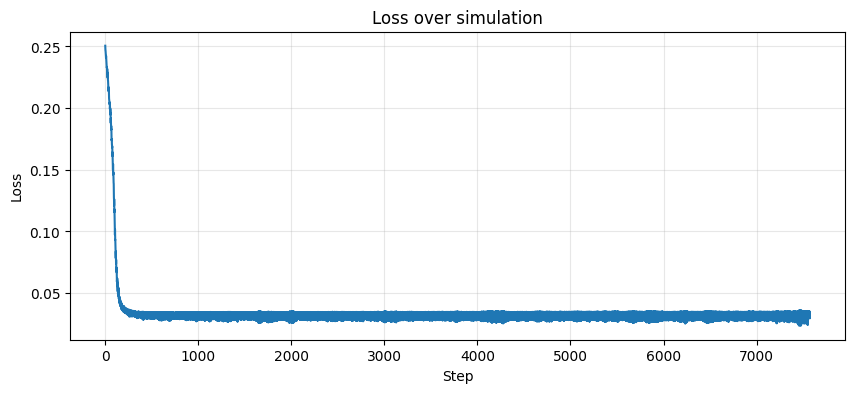

In [15]:
import sys
from threading import Event, Thread

import ipywidgets as widgets
from IPython.display import display

stop_event = Event()
stop_button = widgets.Button(description="Stop simulation", button_style="danger")
stop_status = widgets.HTML(value="<b>Simulation running...</b>")


def on_stop_clicked(_button):
    stop_event.set()
    stop_button.disabled = True
    stop_status.value = "<b>Stop requested. Finishing the current step...</b>"


stop_button.on_click(on_stop_clicked)
display(widgets.HBox([stop_button]), stop_status)


def run_simulation():
    y_true = next(sequ_generator)

    for step, new_value in enumerate(sequ_generator):
        if stop_event.is_set():
            print(f"stopped at step={step}")
            break

        x = y_true
        y_true = new_value

        x_grid, y_grid, y_pred_grid = predict_grid(
            model=srn_subject,
            x=x,
            y_true=y_true,
            unique_vals=unique_vals,
        )

        loss = srn_subject.backprop(y_pred_grid, y_grid)

        y_true_label = unique_vals[y_true]  # get the expected letter
        y_pred = torch.argmax(y_pred_grid).item()
        y_pred_label = unique_vals[y_pred]  # get the predicted letter
        x_label = unique_vals[x]  # get the input letter

        is_correct = y_true_label == y_pred_label
        loss_value = float(loss.item() if hasattr(loss, "item") else loss)
        loss_evolution.append(loss_value)

        print(
            f"step={step}, x={x_label}, y={y_true_label}, y_pred={y_pred_label}, correct={is_correct}, loss={loss_value}",
            end="\r",
        )

        if y_true_label in ["d", "e", "f"]:
            true_predictable.append(is_correct)

    stop_status.value = "<b>Simulation finished.</b>" if not stop_event.is_set() else stop_status.value


simulation_thread = Thread(target=run_simulation, daemon=True)
simulation_thread.start()

def plot_loss_when_done():
    simulation_thread.join()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(loss_evolution, color="tab:blue", linewidth=1.5)
    ax.set_title("Loss over simulation")
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    plt.show()

plot_thread = Thread(target=plot_loss_when_done, daemon=True)
plot_thread.start()


Visibly, with enough simulation steps, the srn can predict a predictable value without error.
For a->d, b->e, c->f and 24 embeddings, the number of possible 3 tuples is:
$$\text{3 steps possibilities} = 3 * 24 = 72 $$
So there is a chance that the srn simply overfit on all the possiblities if there is too much steps.